# VAE Evaluation — Pipeline v2 (WINDOW_SIZE=60)

Identical evaluation protocol to `module3_pipeline/vae_eval.ipynb`: every
threshold calibrated only from `cc1_val` (zero anomalies), PR-AUC as the
primary metric, oracle-ceiling analysis, per-fault-type recall, detection
delay, KS-test drift characterization. Only the underlying model/data
changed (window=60 instead of 30).

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle, json, os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix,
)
from scipy import stats

BASE      = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3'
DATA_DIR  = os.path.join(BASE, 'data', 'processed', 'windows_cc1_v2')
RAW_DIR   = os.path.join(BASE, 'data', 'processed')
MODEL_DIR = os.path.join(BASE, 'models_v2')

DRIFT_SETS = ['drift_cc2']
ALL_SETS   = ['cc1_test'] + DRIFT_SETS

print('Paths configured.')

Paths configured.


## Step 1 — Load model + recompute anomaly scores

In [2]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, hidden1), nn.ReLU(), nn.Linear(hidden1, hidden2), nn.ReLU())
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden2), nn.ReLU(), nn.Linear(hidden2, hidden1), nn.ReLU(), nn.Linear(hidden1, input_dim))
    def encode(self, x):
        h = self.encoder(x); return self.fc_mu(h), torch.clamp(self.fc_lv(h), -10, 10)
    def decode(self, z): return self.decoder(z)
    @torch.no_grad()
    def anomaly_score(self, x):
        self.eval(); mu, _ = self.encode(x); return ((self.decode(mu) - x) ** 2).mean(dim=1)

meta = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_meta.pkl'), 'rb'))
print('Model metadata:', meta)

model = VAE(meta['input_dim'], meta['hidden1'], meta['hidden2'], meta['latent_dim'])
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'vae_cc1.pt'), map_location='cpu'))
model.eval()

CLIP = meta['clip']
X, y, ft, mse = {}, {}, {}, {}
for name in ['cc1_train', 'cc1_val'] + ALL_SETS:
    Xr = np.load(os.path.join(DATA_DIR, f'X_{name}.npy'))
    X[name] = np.clip(Xr, -CLIP, CLIP).astype(np.float32)
    y[name] = np.load(os.path.join(DATA_DIR, f'y_{name}.npy'))
    ft[name] = np.load(os.path.join(DATA_DIR, f'ft_{name}.npy'), allow_pickle=True)
    mse[name] = model.anomaly_score(torch.from_numpy(X[name])).numpy()
    print(f'  {name:10s}: {len(y[name]):>7,} windows  |  anomalies: {int(y[name].sum()):,}  ({y[name].mean()*100:.2f}%)')

assert abs(mse['cc1_train'].mean() - meta['mu_train']) < 1e-3
print(f'\nRecomputed cc1_train MSE matches saved meta baseline. Good.')

Model metadata: {'input_dim': 48, 'hidden1': 64, 'hidden2': 32, 'latent_dim': 32, 'beta_max': 0.01, 'clip': 20.0, 'window_size': 60, 'mu_train': 0.28406664729118347, 'sigma_train': 0.24759788811206818}
  cc1_train : 152,456 windows  |  anomalies: 0  (0.00%)
  cc1_val   :  20,763 windows  |  anomalies: 0  (0.00%)
  cc1_test  :  43,375 windows  |  anomalies: 256  (0.59%)
  drift_cc2 :  76,167 windows  |  anomalies: 1,080  (1.42%)

Recomputed cc1_train MSE matches saved meta baseline. Good.


## Step 2 — Threshold-free quality: PR-AUC (primary) vs. ROC-AUC

set            PR-AUC (primary)   ROC-AUC   n_anom  anom_rate  PR-AUC lift
cc1_test                 0.9178    0.9855      256      0.59%       155.5x
drift_cc2                0.3307    0.9129    1,080      1.42%        23.3x


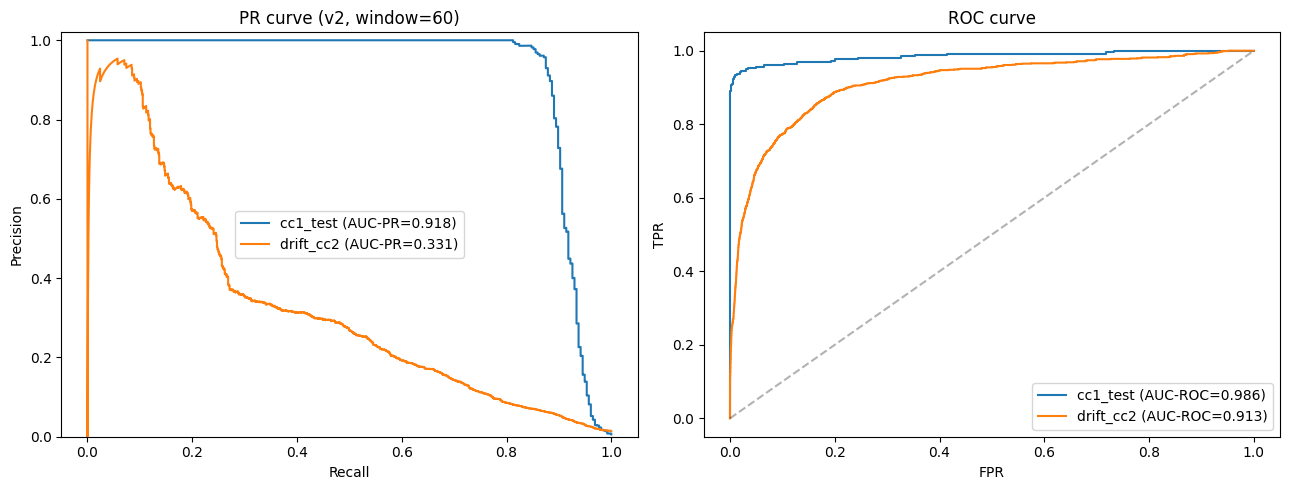

In [3]:
auc_results = {}
for name in ALL_SETS:
    auc_results[name] = {'auc_roc': roc_auc_score(y[name], mse[name]), 'auc_pr': average_precision_score(y[name], mse[name])}

print(f'{"set":12s} {"PR-AUC (primary)":>18s} {"ROC-AUC":>9s} {"n_anom":>8s} {"anom_rate":>10s} {"PR-AUC lift":>12s}')
for name in ALL_SETS:
    base_rate = y[name].mean()
    lift = auc_results[name]['auc_pr'] / base_rate
    print(f'{name:12s} {auc_results[name]["auc_pr"]:18.4f} {auc_results[name]["auc_roc"]:9.4f} '
          f'{int(y[name].sum()):8,} {base_rate*100:9.2f}% {lift:11.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in ALL_SETS:
    p, r, _ = precision_recall_curve(y[name], mse[name])
    axes[0].plot(r, p, label=f'{name} (AUC-PR={auc_results[name]["auc_pr"]:.3f})')
    fpr, tpr, _ = roc_curve(y[name], mse[name])
    axes[1].plot(fpr, tpr, label=f'{name} (AUC-ROC={auc_results[name]["auc_roc"]:.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_title('PR curve (v2, window=60)'); axes[0].legend(); axes[0].set_ylim(0, 1.02)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('ROC curve'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_eval_pr_roc_curves.png'), dpi=120)
plt.show()

## Step 3 — Leak-free operating-point threshold (`val_p99`)

In [4]:
val_p99 = float(np.percentile(mse['cc1_val'], 99))
fpr_on_val = (mse['cc1_val'] > val_p99).mean()
print(f'val_p99 threshold={val_p99:.5f}   flags {fpr_on_val*100:.2f}% of cc1_val (all normal)')
THRESHOLDS = {'val_p99': val_p99}

val_p99 threshold=1.44733   flags 1.00% of cc1_val (all normal)


## Step 4 — Precision / Recall / F1 / FPR at the operating point

In [5]:
print(f'{"set":12s} {"precision":>10s} {"recall":>8s} {"f1":>7s} {"FPR":>7s} {"TP":>5s} {"FP":>6s} {"FN":>5s} {"TN":>7s}')
pr_results = {}
for name in ALL_SETS:
    pred = (mse[name] > val_p99).astype(int)
    p = precision_score(y[name], pred, zero_division=0)
    r = recall_score(y[name], pred, zero_division=0)
    f1 = f1_score(y[name], pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y[name], pred).ravel()
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
    pr_results[name] = {'val_p99': {'precision': p, 'recall': r, 'f1': f1, 'fpr': fpr_val, 'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn)}}
    print(f'{name:12s} {p:10.3f} {r:8.3f} {f1:7.3f} {fpr_val:7.4f} {tp:5d} {fp:6d} {fn:5d} {tn:7d}')

set           precision   recall      f1     FPR    TP     FP    FN      TN
cc1_test          0.986    0.848   0.912  0.0001   217      3    39   43116
drift_cc2         0.086    0.800   0.155  0.1230   864   9233   216   65854


## Step 5 — Oracle-ceiling analysis

In [6]:
oracle_results = {}
print(f'{"set":12s} {"deployed F1":>13s} {"oracle-best F1":>15s} {"gap":>8s} {"oracle P":>9s} {"oracle R":>9s}')
for name in ALL_SETS:
    p, r, t = precision_recall_curve(y[name], mse[name])
    f1s = 2 * p * r / (p + r + 1e-12)
    i = np.argmax(f1s)
    deployed_f1 = pr_results[name]['val_p99']['f1']
    oracle_results[name] = {'f1': float(f1s[i]), 'precision': float(p[i]), 'recall': float(r[i])}
    print(f'{name:12s} {deployed_f1:13.4f} {f1s[i]:15.4f} {f1s[i]-deployed_f1:8.4f} {p[i]:9.3f} {r[i]:9.3f}')

set            deployed F1  oracle-best F1      gap  oracle P  oracle R
cc1_test            0.9118          0.9143   0.0025     0.957     0.875
drift_cc2           0.1546          0.3613   0.2067     0.293     0.470


## Step 6 — Per-fault-type recall

cc1_test     cpu            n=   88  recall=0.761
cc1_test     memory         n=   76  recall=0.868
cc1_test     pod-failure    n=   92  recall=0.913
drift_cc2    cpu            n=  297  recall=0.879
drift_cc2    memory         n=  594  recall=0.852
drift_cc2    pod-failure    n=  189  recall=0.513


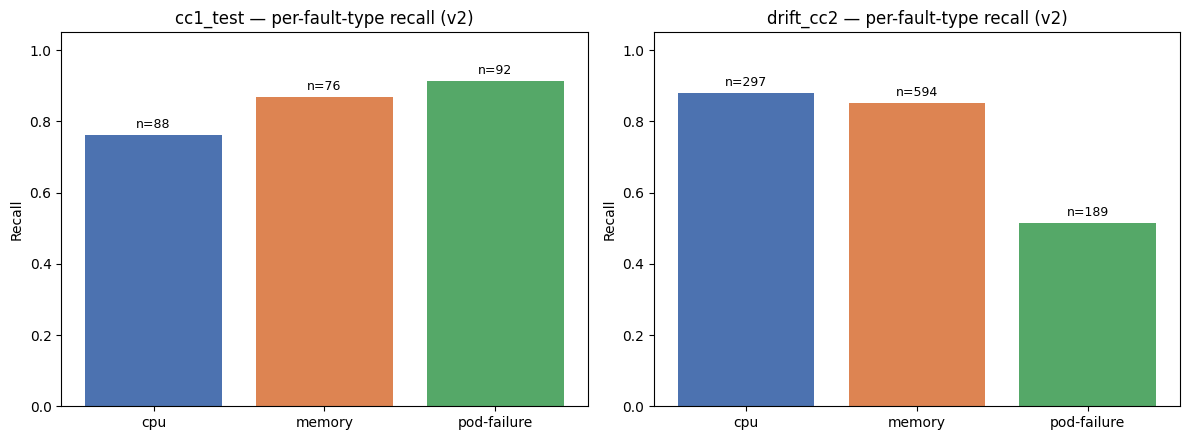

In [7]:
OP_POINT = 'val_p99'
t = THRESHOLDS[OP_POINT]
per_fault_results = {}
for name in ALL_SETS:
    per_fault_results[name] = {}
    pred = (mse[name] > t).astype(int)
    for ftype in sorted({v for v in ft[name] if isinstance(v, str)}):
        mask = (ft[name] == ftype)
        n = int(mask.sum())
        rec = pred[mask].mean() if n > 0 else float('nan')
        per_fault_results[name][ftype] = {'n': n, 'recall': rec}
        print(f'{name:12s} {ftype:14s} n={n:5d}  recall={rec:.3f}')

fig, axes = plt.subplots(1, len(ALL_SETS), figsize=(6 * len(ALL_SETS), 4.5))
if len(ALL_SETS) == 1: axes = [axes]
for ax, name in zip(axes, ALL_SETS):
    ftypes = list(per_fault_results[name].keys())
    recalls = [per_fault_results[name][f]['recall'] for f in ftypes]
    ns = [per_fault_results[name][f]['n'] for f in ftypes]
    bars = ax.bar(ftypes, recalls, color=['#4C72B0', '#DD8452', '#55A868'][:len(ftypes)])
    for bar, n in zip(bars, ns):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'n={n}', ha='center', fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_ylabel('Recall'); ax.set_title(f'{name} — per-fault-type recall (v2)')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_eval_per_fault.png'), dpi=120)
plt.show()

## Step 7 — Detection delay (`drift_cc2`, groundtruth-based)

In [8]:
GT_PATH = os.path.join(BASE, 'data', 'raw', 'Complex Case-2', 'Case-2', 'groundtruth', 'groundtruth.json')
with open(GT_PATH) as f:
    gt = json.load(f)
gt_df = pd.DataFrame(gt)
gt_df = gt_df[~gt_df['failure_type'].isin(['delay', 'loss'])].reset_index(drop=True)

df_cc2 = pd.read_csv(os.path.join(RAW_DIR, 'drift_complex_case2.csv'), low_memory=False)
df_cc2['is_gap'] = df_cc2['is_gap'].astype(bool)

WINDOW_SIZE = meta.get('window_size', 60)
pred_cc2 = (mse['drift_cc2'] > THRESHOLDS['val_p99']).astype(int)

end_ts_list, cmdb_list = [], []
for cmdb_id, g in df_cc2.sort_values('timestamp').groupby('cmdb_id'):
    is_gap = g['is_gap'].values
    ts = g['timestamp'].values
    n = len(g)
    for i in range(0, n - WINDOW_SIZE + 1, 1):
        if is_gap[i:i + WINDOW_SIZE].any():
            continue
        end_ts_list.append(ts[i + WINDOW_SIZE - 1])
        cmdb_list.append(cmdb_id)
end_ts_arr = np.array(end_ts_list)
cmdb_arr = np.array(cmdb_list)
assert len(end_ts_arr) == len(pred_cc2), 'window count mismatch'

delays = []
for _, row in gt_df.iterrows():
    short_id = row['cmdb_id']
    full_id = f'observe.{short_id}'
    onset, duration = row['timestamp'], row['duration']
    mask = (cmdb_arr == full_id) & (end_ts_arr >= onset) & (end_ts_arr < onset + duration + WINDOW_SIZE * 15)
    if not mask.any():
        continue
    idx = np.where(mask)[0]
    idx_sorted = idx[np.argsort(end_ts_arr[idx])]
    flagged = idx_sorted[pred_cc2[idx_sorted] == 1]
    if len(flagged) == 0:
        delays.append({'cmdb_id': short_id, 'failure_type': row['failure_type'], 'detected': False, 'delay_sec': None})
    else:
        delay_sec = int(end_ts_arr[flagged[0]] - onset)
        delays.append({'cmdb_id': short_id, 'failure_type': row['failure_type'], 'detected': True, 'delay_sec': delay_sec})

delay_df = pd.DataFrame(delays)
print(delay_df.to_string(index=False))
detected = delay_df[delay_df['detected']]
print(f'\nDetection rate: {len(detected)}/{len(delay_df)} events ({len(detected)/len(delay_df)*100:.0f}%)')
if len(detected):
    print(f'Mean delay: {detected["delay_sec"].mean():.0f}s   Median delay: {detected["delay_sec"].median():.0f}s')

          cmdb_id failure_type  detected  delay_sec
       frontend-0       memory      True         90
       frontend-1       memory      True        105
       frontend-2       memory      True        180
currencyservice-0          cpu      True        135
currencyservice-1          cpu      True        120
currencyservice-2          cpu      True        105
    cartservice-0  pod-failure      True         45
    cartservice-1  pod-failure      True         90
    cartservice-2  pod-failure      True        105
       frontend-0       memory      True        165
       frontend-1       memory      True        180
       frontend-2       memory      True        105

Detection rate: 12/12 events (100%)
Mean delay: 119s   Median delay: 105s


## Step 8 — KS-test drift characterization

In [9]:
ks_results = {}
ref = mse['cc1_train']
for name in DRIFT_SETS:
    normal_mse = mse[name][y[name] == 0]
    ks_stat, p_value = stats.ks_2samp(ref, normal_mse)
    verdict = 'REAL DRIFT (p<0.001)' if p_value < 0.001 else ('mild shift' if p_value < 0.05 else 'no significant shift')
    ks_results[name] = {'ks_stat': float(ks_stat), 'p_value': float(p_value)}
    print(f'{name:12s}  KS stat={ks_stat:.4f}  p-value={p_value:.2e}  {verdict}')

drift_cc2     KS stat=0.5600  p-value=0.00e+00  REAL DRIFT (p<0.001)


## Step 9 — Consolidated summary dashboard

=== FINAL METRICS SUMMARY (v2, window=60) ===

           PR-AUC (primary)  ROC-AUC  F1 @ val_p99  Precision  Recall     FPR  Oracle-best F1
set                                                                                          
cc1_test             0.9178   0.9855        0.9118     0.9864  0.8477  0.0001          0.9143
drift_cc2            0.3307   0.9129        0.1546     0.0856  0.8000  0.1230          0.3613


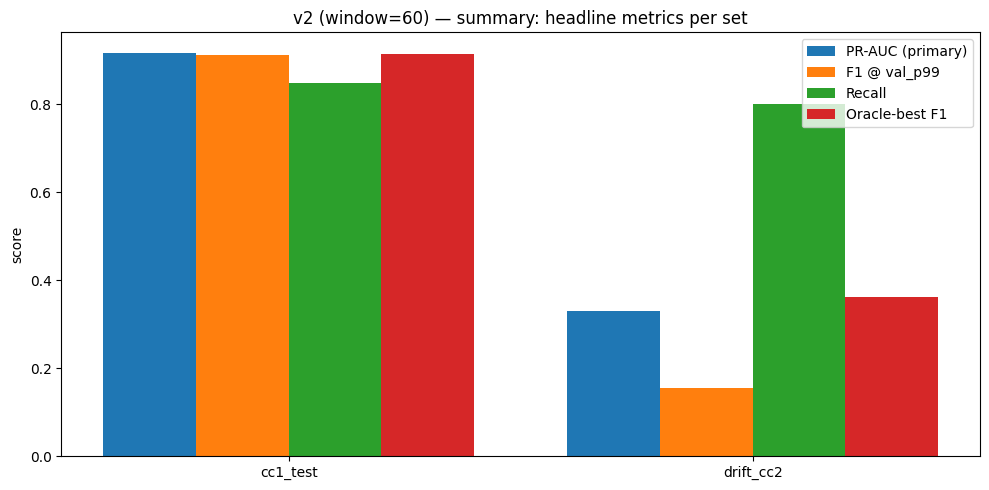

In [10]:
print('=== FINAL METRICS SUMMARY (v2, window=60) ===\n')
summary_rows = []
for name in ALL_SETS:
    row = {
        'set': name,
        'PR-AUC (primary)': auc_results[name]['auc_pr'],
        'ROC-AUC': auc_results[name]['auc_roc'],
        'F1 @ val_p99': pr_results[name]['val_p99']['f1'],
        'Precision': pr_results[name]['val_p99']['precision'],
        'Recall': pr_results[name]['val_p99']['recall'],
        'FPR': pr_results[name]['val_p99']['fpr'],
        'Oracle-best F1': oracle_results[name]['f1'],
    }
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index('set')
print(summary_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = ['PR-AUC (primary)', 'F1 @ val_p99', 'Recall', 'Oracle-best F1']
x = np.arange(len(ALL_SETS)); width = 0.2
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, summary_df[metric], width, label=metric)
ax.set_xticks(x + width * 1.5); ax.set_xticklabels(ALL_SETS)
ax.set_ylabel('score'); ax.set_title('v2 (window=60) — summary: headline metrics per set')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_eval_summary_dashboard.png'), dpi=120)
plt.show()

## Step 10 — Save evaluation results

In [11]:
eval_results = {
    'thresholds': THRESHOLDS,
    'auc': auc_results,
    'precision_recall': pr_results,
    'oracle_ceiling': oracle_results,
    'per_fault_recall': per_fault_results,
    'detection_delay': delay_df.to_dict('records'),
    'ks_drift': ks_results,
    'operating_point': OP_POINT,
    'summary_table': summary_df.to_dict(),
}
eval_path = os.path.join(MODEL_DIR, 'vae_cc1_eval.pkl')
with open(eval_path, 'wb') as f:
    pickle.dump(eval_results, f)
print(f'Saved -> {eval_path}')

Saved -> c:\Users\jthar\Documents\Claude\Projects\module3\module3\models_v2\vae_cc1_eval.pkl


## Summary

| Output | Contents |
|---|---|
| `models_v2/vae_cc1_eval.pkl` | every metric computed in this notebook |
| `vae_cc1_eval_pr_roc_curves.png`, `_per_fault.png`, `_summary_dashboard.png` | figures |

**Next:** `adaptive_threshold_blended.ipynb` (v2) — implements the blended
threshold with the k derived from this notebook's own `val_p99`/`mu_train`/
`sigma_train`, rather than assuming a fixed multiplier.